In [552]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))
from lib_equations import euler, back_euler, rk2, rk4
# import lib_plot

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **RK2**

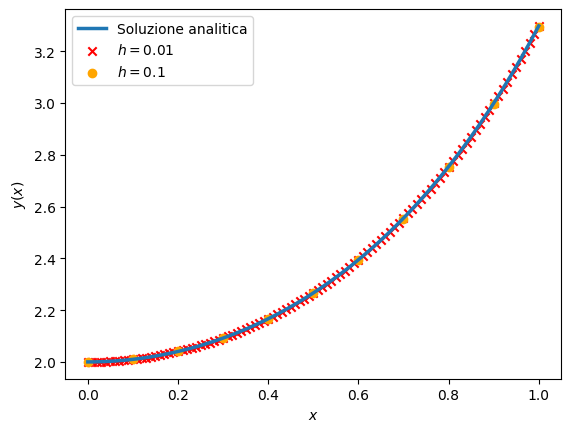

In [553]:
# y'= x*y
# y0 = 2

f_dx = lambda x, y: x * y
y0 = 2
xmax = 1

xcoo = np.linspace(0, xmax, 100)
# analytic sol
ycoo = 2*np.exp(xcoo**2 / 2)
plt.plot(xcoo, ycoo, label='Soluzione analitica', lw=2.5)

for couple in [(0.01, 'x', 'red'), (0.1, 'o', 'orange')]:
    h, mar, col = couple
    x_span = np.arange(0, xmax + h, h) 
    res = rk2(f_dx, y0, x_span)
    plt.scatter(x_span, res, color=col, marker=mar, label=rf'$h = {h}$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y(x)$')
plt.legend()
plt.show()

## **RK4**

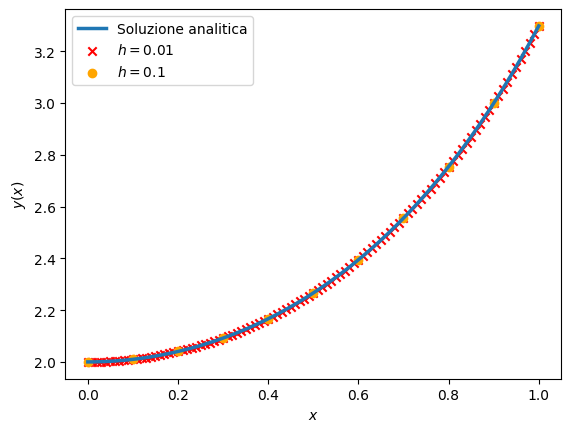

In [554]:
plt.plot(xcoo, ycoo, label='Soluzione analitica', lw=2.5)

for couple in [(0.01, 'x', 'red'), (0.1, 'o', 'orange')]:
    h, mar, col = couple
    x_span = np.arange(0, xmax + h, h) 
    res = rk4(f_dx, y0, x_span)
    plt.scatter(x_span, res, color=col, marker=mar, label=rf'$h = {h}$')
plt.xlabel(r'$x$')
plt.ylabel(r'$y(x)$')
plt.legend()
plt.show()

## **Pendolo semplice**

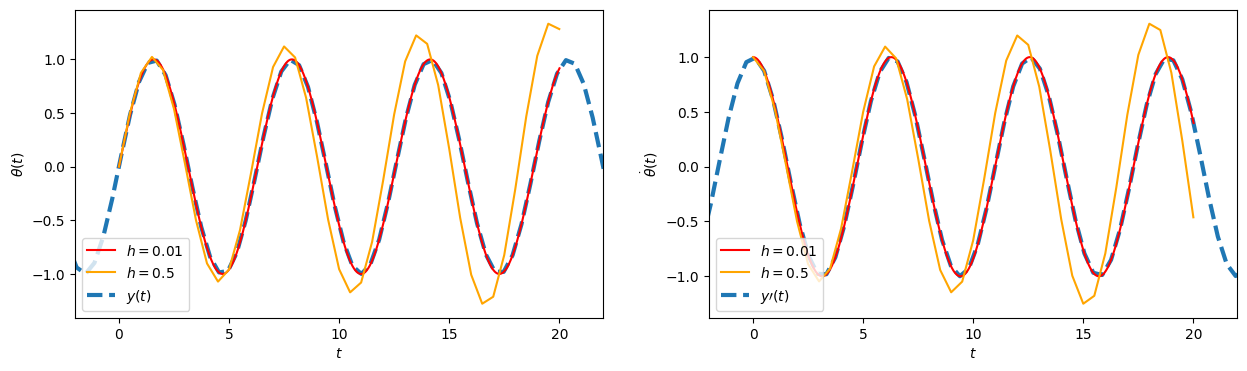

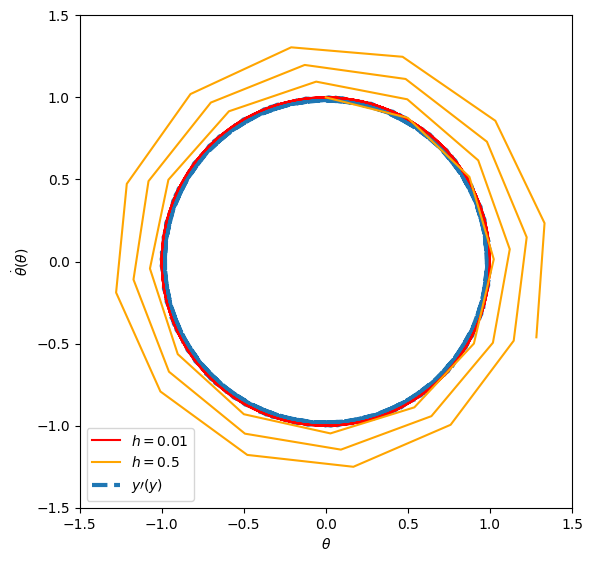

<Figure size 640x480 with 0 Axes>

In [555]:
# y''= -y
# y0 = 0
# y'0 = 1

f_dx = lambda x, th : np.array([[0,1], [-1, 0]]) @ th
y0s = np.array([0, 1])
xmax = 20

xcoo = np.linspace(-10, xmax+10, 100)
# analytic sol
ycoo = np.sin(xcoo)
ypcoo = np.cos(xcoo)

# plot
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
circ_fig, circ_ax = plt.subplots(figsize=(6, 6))
for couple in [(0.01, 'X', 'red'), (0.5, 'o', 'orange')]:
    h, mar, col = couple
    x_span = np.arange(0, xmax + h, h) 
    res = rk2(f_dx, y0s, x_span)
    th_0 = res[:, 0]
    th_p = res[:, 1]
    coord = [
        [x_span, th_0],
        [x_span, th_p],
    ]
    for i, coo in enumerate(coord):
        x, y = coo 
        axi = ax[i]
        axi.plot(x, y, color=col, label=rf'$h = {h}$', zorder=2)
        axi.set_xlabel(r'$t$')
        axi.legend()
        axi.set_xlim(-2, 22)
        
    x, y = [th_0, th_p] 
    axi = circ_ax
    axi.plot(x, y, color=col, label=rf'$h = {h}$', zorder=2)
    axi.set_xlabel(r'$\theta$')
    axi.legend()

ax[0].plot(xcoo, ycoo, label=r'$y(t)$', lw=3, ls= '--', zorder=1)
ax[0].set_ylabel(r'$\theta(t)$')
ax[0].legend(loc='lower left')

ax[1].plot(xcoo, ypcoo, label=r'$y\prime(t)$', lw=3, ls= '--', zorder=1)
ax[1].set_ylabel(r'$\dot \theta(t)$')
ax[1].legend(loc='lower left')

s_lims = 1.5
circ_ax.set_ylabel(r'$\dot \theta (\theta)$')
circ_ax.plot(ycoo, ypcoo, label=r'$y\prime (y)$', lw=3, ls= '--', zorder=1)
circ_ax.set_xlim(-s_lims, s_lims)
circ_ax.set_ylim(-s_lims, s_lims)
circ_ax.set_aspect('equal', adjustable='box')
circ_ax.legend()

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

## **Confronti RK-Euler**

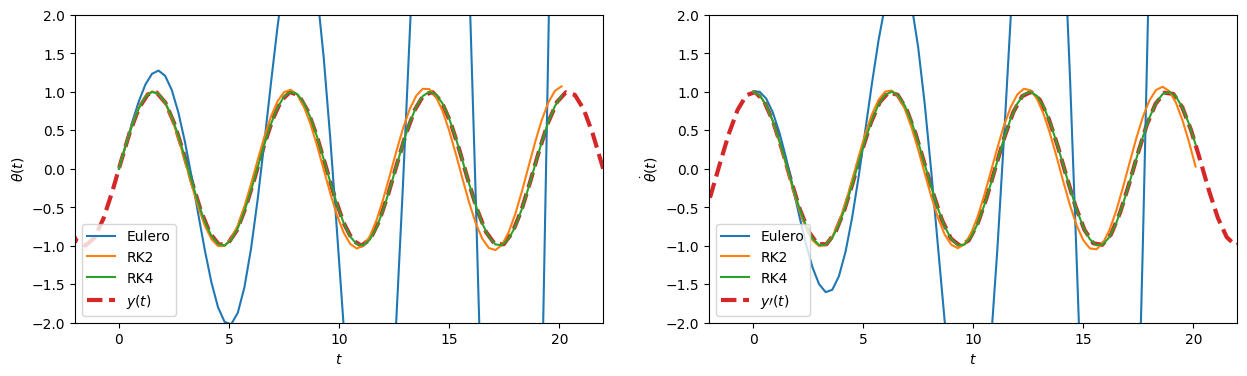

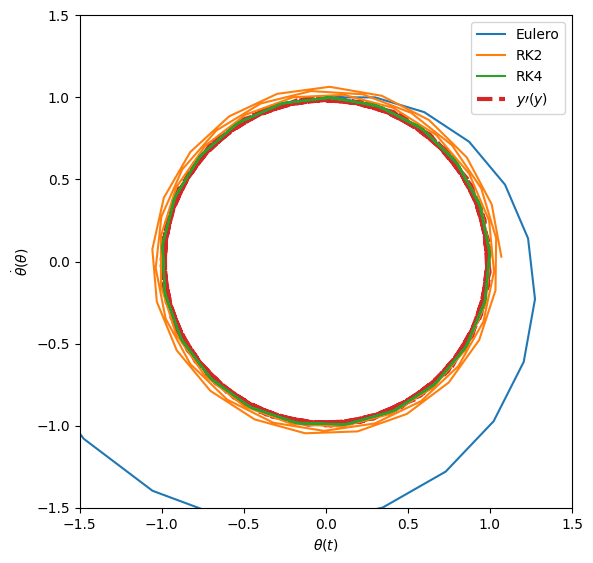

In [556]:
h = 0.3
x_span = np.arange(0, xmax + h, h) 

# plot
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
circ_fig, circ_ax = plt.subplots(figsize=(6, 6))

for couple in [('Eulero', euler, 'X'), ('RK2', rk2, 'X'), ('RK4', rk4, 'X')]:
    name, method, mar = couple
    res = method(f_dx, y0s, x_span)
    th_0 = res[:, 0]
    th_p = res[:, 1]
    coord = [
        [x_span, th_0],
        [x_span, th_p],
    ]
    for i, coo in enumerate(coord):
        x, y = coo 
        axi = ax[i]
        axi.plot(x, y, label=name, zorder=2)
        axi.set_xlabel(r'$t$')
        axi.set_xlim(-2, 22)
        axi.set_ylim(-2, 2)
        
    x, y = [th_0, th_p] 
    axi = circ_ax
    axi.plot(x, y, label=name, zorder=2)
    axi.set_xlabel(r'$\theta(t)$')

ax[0].plot(xcoo, ycoo, label=r'$y(t)$', lw=3, ls= '--', zorder=1)
ax[0].set_ylabel(r'$\theta(t)$')
ax[0].legend(loc='lower left')

ax[1].plot(xcoo, ypcoo, label=r'$y\prime(t)$', lw=3, ls= '--', zorder=1)
ax[1].set_ylabel(r'$\dot \theta(t)$')
ax[1].legend(loc='lower left')

s_lims = 1.5
circ_ax.set_ylabel(r'$\dot \theta (\theta)$')
circ_ax.plot(ycoo, ypcoo, label=r'$y\prime (y)$', lw=3, ls= '--', zorder=1)
circ_ax.set_xlim(-s_lims, s_lims)
circ_ax.set_ylim(-s_lims, s_lims)
circ_ax.set_aspect('equal', adjustable='box')
circ_ax.legend()

plt.tight_layout()
plt.show()